### Implementing Simple Chatbot using langgraph 

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
from langchain_groq import ChatGroq
import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

llm.invoke("Hello How are you doing ?")

AIMessage(content="Hello! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The system message says we are ChatGPT, with no special constraints beyond typical. The user says "Hello How are you doing ?" We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 77, 'total_tokens': 142, 'completion_time': 0.137654262, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.026009078, 'prompt_tokens_details': None, 'queue_time': 0.351014011, 'total_time': 0.16366334}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_0708ac49a5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09a55-b95e-7123-9eeb-5939dc8f83c5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 65, 'total_tokens': 142, 'output_token_details': {'reasoning': 39}}

In [4]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state:State):
    return {"messages":llm.invoke(state['messages'])}

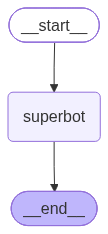

In [5]:
from IPython.display import Image,display

graph = StateGraph(State)
graph.add_node("superbot",superbot)
graph.add_edge(START , "superbot")
graph.add_edge("superbot",END)
graph_memoryy = graph.compile(checkpointer=memory)
display(Image(graph_memoryy.get_graph().draw_mermaid_png()))

In [7]:
config = {"configurable": {"thread_id": "1"}}
graph_memoryy.invoke({"messages":"Hello what can you help me with"},config=config)

{'messages': [HumanMessage(content='Hello what can you help me with', additional_kwargs={}, response_metadata={}, id='b048e7b1-6bec-4d74-a707-9167d824a2db'),
  AIMessage(content='Hello! I’m here to help with a wide range of tasks, such as:\n\n* **Answering questions** – from simple facts to deeper explanations in science, history, technology, literature, and more.  \n* **Writing and editing** – essays, articles, emails, stories, poems, social‑media posts, resumes, cover letters, etc.  \n* **Learning support** – breaking down concepts, tutoring in math, programming, languages, and other subjects.  \n* **Creative brainstorming** – ideas for projects, plot twists, marketing campaigns, product names, and more.  \n* **Programming assistance** – writing, debugging, and explaining code in many languages, plus algorithm design and best‑practice advice.  \n* **Data‑related help** – interpreting tables, generating sample data, explaining statistics, creating simple visualizations (described in t

### Streaming a response 

In [ ]:
for event in graph_memoryy.stream({"messages":"Hello what can you help me with"}):
    print(event)

{'superbot': {'messages': AIMessage(content='Hello! I’m here to help with a wide range of tasks, such as:\n\n- **Answering questions** – from everyday facts to deeper explanations in science, history, technology, and more.  \n- **Learning & tutoring** – breaking down complex concepts, walking through math problems, language learning, etc.  \n- **Writing & editing** – drafting emails, essays, stories, reports, resumes, social‑media posts, or polishing existing text.  \n- **Creative brainstorming** – generating ideas for projects, marketing copy, plot twists, game mechanics, recipes, and more.  \n- **Programming assistance** – explaining code, debugging, writing snippets in many languages, helping with algorithms or software design.  \n- **Research support** – summarizing information, comparing options, outlining pros/cons, or pointing you toward useful resources.  \n- **Practical help** – planning schedules, making checklists, offering travel tips, budgeting ideas, etc.  \n\nIf you have

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

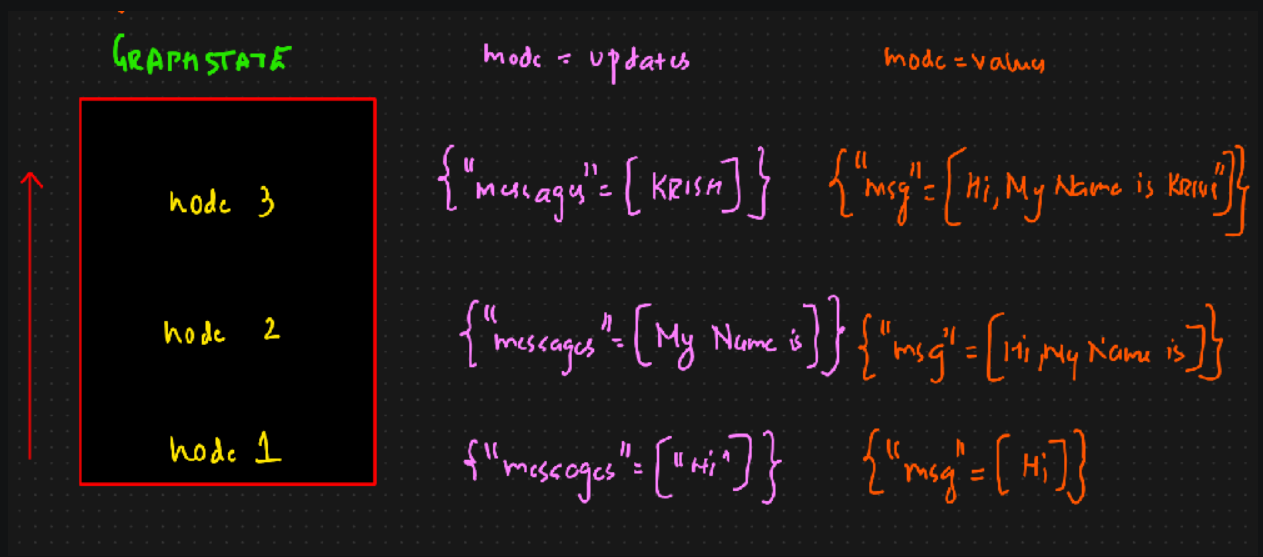

### Streaming the response with Stream METHOD

In [9]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_memoryy.stream({"messages":"Hi , My name is SHAURYA BANSAL And I like basketball"},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': AIMessage(content="Hello Shaurya! 👋 Great to meet you.  \n\nBasketball is such an exciting sport—whether you love watching the games, playing on the court, or following your favorite team. Do you have a favorite NBA team or a player you look up to? Or maybe you enjoy playing a particular position yourself? I'd love to hear more about what draws you to basketball!", additional_kwargs={'reasoning_content': 'The user says: "Hi , My name is SHAURYA BANSAL And I like basketball". Probably they want a response, greeting, maybe ask about basketball. There\'s no request beyond greeting. So respond friendly, maybe ask about favorite team, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 86, 'total_tokens': 228, 'completion_time': 0.294430548, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.004111442, 'prompt_tokens_details': None, 'queue_time': 0.347939334, 'total_time': 0.29854199}, 'model_

In [10]:

for chunk in graph_memoryy.stream({"messages":"Hi , My name is SHAURYA BANSAL And I like basketball"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi , My name is SHAURYA BANSAL And I like basketball', additional_kwargs={}, response_metadata={}, id='b95d4658-bdf8-4bed-9fe6-df4909915650'), AIMessage(content="Hello Shaurya! 👋 Great to meet you.  \n\nBasketball is such an exciting sport—whether you love watching the games, playing on the court, or following your favorite team. Do you have a favorite NBA team or a player you look up to? Or maybe you enjoy playing a particular position yourself? I'd love to hear more about what draws you to basketball!", additional_kwargs={'reasoning_content': 'The user says: "Hi , My name is SHAURYA BANSAL And I like basketball". Probably they want a response, greeting, maybe ask about basketball. There\'s no request beyond greeting. So respond friendly, maybe ask about favorite team, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 86, 'total_tokens': 228, 'completion_time': 0.294430548, 'completion_tokens_det

In [11]:

for chunk in graph_memoryy.stream({"messages":" I also like football"},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': AIMessage(content='Awesome—so you’re a fan of both basketball **and** football! 🎉 It’s great to have a mix of sports to enjoy.\n\n### Quick dive into each sport\n\n| Sport | What many fans love | Popular leagues/competitions |\n|-------|---------------------|------------------------------|\n| **Basketball** | Fast‑paced action, slam dunks, three‑point shooting, strategic ball‑movement | NBA, EuroLeague, NCAA March Madness |\n| **Football (soccer)** | Global passion, tactical battles, incredible goals, club & country rivalries | Premier League, La\u202fLiga, Bundesliga, UEFA Champions League, World Cup |\n\n### A few fun questions to keep the chat going\n\n1. **Basketball side:**  \n   - Do you have a favorite NBA team or player?  \n   - Do you play a particular position on the court?\n\n2. **Football side:**  \n   - Which league or club do you follow most closely?  \n   - Are you more into club football, international tournaments, or both?\n\n3. **Cross‑sport 

In [13]:

for chunk in graph_memoryy.stream({"messages":" I love sports"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi , My name is SHAURYA BANSAL And I like basketball', additional_kwargs={}, response_metadata={}, id='b95d4658-bdf8-4bed-9fe6-df4909915650'), AIMessage(content="Hello Shaurya! 👋 Great to meet you.  \n\nBasketball is such an exciting sport—whether you love watching the games, playing on the court, or following your favorite team. Do you have a favorite NBA team or a player you look up to? Or maybe you enjoy playing a particular position yourself? I'd love to hear more about what draws you to basketball!", additional_kwargs={'reasoning_content': 'The user says: "Hi , My name is SHAURYA BANSAL And I like basketball". Probably they want a response, greeting, maybe ask about basketball. There\'s no request beyond greeting. So respond friendly, maybe ask about favorite team, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 86, 'total_tokens': 228, 'completion_time': 0.294430548, 'completion_tokens_det

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [15]:
config = {"configurable":{"thread_id":"3"}}

async for event in graph_memoryy.astream_events({"messages":"Hi , My name is SHAURYA BANSAL And I like basketball"},config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi , My name is SHAURYA BANSAL And I like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a09a61-1a9d-7942-9f1c-10bbcf0f853b', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi , My name is SHAURYA BANSAL And I like basketball', additional_kwargs={}, response_metadata={}, id='19863b6c-028c-447f-a610-8c451fa9ab11'), AIMessage(content="Hello Shaurya! 👋 Great to meet you.  \n\nBasketball is such an exciting sport—do you have a favorite team or player? Do you play yourself, or are you more of a fan watching the games? I'd love to hear more about what you enjoy about basketball!", additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi , My name is SHAURYA BANSAL And I like basketball". Probably just greeting. We can respond friendly, ask about basketball preferences. No disallowed 